# Postural State — Kinematic Axis (HSI 1.3)

Deterministic rule producing the `postural_state` categorical reading for the `kinematic` domain (RFC-HSI-0010): the body's orientation relative to gravity.

## Overview
- Objective: report coarse body posture so downstream physiology can be read in context. Heart rate, for example, is higher standing than lying, so posture tells the system whether an HR change reflects body position rather than stress or exertion. The largest such orthostatic difference is lying vs upright, which is also the distinction gravity separates most cleanly.
- Orientation-dependent by design: this axis reads the gravity **direction** (the low-frequency component of the accelerometer), deliberately breaking the magnitude / orientation-invariant convention used by the motion axes. Posture *is* gravity direction, so that information is kept, not discarded.
- Output (v1): three classes — `lying`, `upright`, `in_motion`.
  - `upright` is an explicit merge of sitting and standing. The mentor taxonomy lists four static postures, but on this data sitting and standing differ by only a small tilt angle (Section 6), below single-accelerometer resolution. Three classes are emitted and the merge is documented as a measured proposal back to the mentor.
  - `in_motion` marks a window that is actively moving; static posture is deferred for that window.
- Sensor: PAMAP2 chest accelerometer (trunk), raw — gravity retained, because gravity is the signal.
- Sampling: 100 Hz. Window: 5 s (500 samples), 50% overlap (consistent with movement_regularity).
- Classifier: deterministic rule (fixed thresholds; no training). Calibration is a per-subject self-reference from that subject's own standing windows.
- Scope of this notebook: the rule and its validation. No confidence and no HSI emission this loop.

## 1. Setup and configuration
Imports and all constants in one place.

In [1]:
import re, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix

mpl.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "font.size": 11,
    "legend.fontsize": 10,
})

In [2]:
# Sampling and windowing
SAMPLE_RATE = 100                       # PAMAP2 IMU rate (Hz); chest accel is not downsampled here
WINDOW_SEC = 5.0                        # window length (s), consistent with movement_regularity
WINDOW = int(WINDOW_SEC * SAMPLE_RATE)  # 500 samples
STEP = WINDOW // 2                      # 50% overlap

# Deterministic rule thresholds
MOVE_T = 1.0      # std of |accel| above this (chest m/s^2) -> the body is moving -> in_motion
TILT_T = 65.0     # tilt from calibrated "up" above this (deg) -> lying; below -> upright.
                  # 65 deg is the literature lying-vs-upright cut-point and sits above the upright spread (Section 4).

# PAMAP2 chest (trunk) accelerometer columns in the .dat file; raw (gravity kept)
CHEST_ACC = [21, 22, 23]
CALIB_ACTIVITY = 3                      # standing: the per-subject "up" reference (see calibration caveat in Findings)
ACTIVITY_NAMES = {1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running", 6: "cycling",
                  7: "nordic_walk", 12: "ascend_stairs", 13: "descend_stairs", 16: "vacuum",
                  17: "ironing", 24: "rope_jump"}

# Expected posture per activity, for validation. vacuum is excluded (the torso bends; posture is ambiguous).
TRUE_POSTURE = {"lying": "lying",
                "sitting": "upright", "standing": "upright", "ironing": "upright",
                "walking": "in_motion", "running": "in_motion", "cycling": "in_motion",
                "nordic_walk": "in_motion", "ascend_stairs": "in_motion",
                "descend_stairs": "in_motion", "rope_jump": "in_motion"}

CLASSES = ["lying", "upright", "in_motion"]
CLASS_COLOR = {"lying": "#DD8452", "upright": "#55A868", "in_motion": "#4C72B0"}

PAMAP2_GLOB = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset/Protocol/*.dat"

## 2. Posture rule (deterministic)
A three-branch rule on one window. `gravity_vector` is the window mean of the raw accelerometer — when the body is still it points straight down, so it is the gravity direction. `tilt_angle` is the angle between that direction and the calibrated upright reference. A moving window (std of |accel| above `MOVE_T`) is `in_motion`; otherwise a small tilt is `upright` and a large tilt is `lying`.

In [3]:
def gravity_vector(window_xyz):
    """Mean accelerometer over the window ~ gravity direction when the body is still."""
    return window_xyz.mean(axis=0)

def tilt_angle(g, up):
    """Angle (deg) between two vectors; here gravity-now vs the calibrated upright reference."""
    g = g / (np.linalg.norm(g) + 1e-9)
    up = up / (np.linalg.norm(up) + 1e-9)
    return np.degrees(np.arccos(np.clip(g @ up, -1.0, 1.0)))

def window_posture(window_xyz, up):
    """Return (movement, tilt, label) for one window. up = the subject's standing gravity vector."""
    movement = float(np.sqrt((window_xyz ** 2).sum(axis=1)).std())
    tilt = float(tilt_angle(gravity_vector(window_xyz), up))
    if movement > MOVE_T:
        label = "in_motion"                       # actively moving: static posture deferred
    else:
        label = "upright" if tilt < TILT_T else "lying"
    return movement, tilt, label

## 3. PAMAP2 loader and per-subject calibration
For each subject the upright reference `up` is the mean gravity vector over that subject's labeled standing windows. Five-second windows are then slid within each activity run (no mixing across activities) and the rule is applied, keeping the true activity beside each verdict. Windows with gaps are skipped — posture needs gravity, so broken data is not guessed. A subject with no labeled standing cannot be calibrated and is dropped (noted in Findings).

In [4]:
calib = {}      # subject -> {"stand": standing gravity vector, "sit": sitting gravity vector}
rows = []
for path in sorted(glob.glob(PAMAP2_GLOB)):
    subj = int(re.search(r"subject(\d+)", path).group(1))
    raw = pd.read_csv(path, sep=r"\s+", header=None, usecols=[1] + CHEST_ACC)
    act = raw[1].to_numpy()
    xyz = raw[CHEST_ACC].to_numpy()

    stand = xyz[act == CALIB_ACTIVITY]
    stand = stand[~np.isnan(stand).any(axis=1)]
    if len(stand) == 0:
        print(f"subject {subj}: no labeled standing -> cannot calibrate, skipped")
        continue
    up = stand.mean(axis=0)                                # per-subject upright reference
    sit = xyz[act == 2]; sit = sit[~np.isnan(sit).any(axis=1)]
    calib[subj] = {"stand": up, "sit": sit.mean(axis=0) if len(sit) else None}

    change = np.where(np.diff(act) != 0)[0] + 1            # activity boundaries
    for s0, e0 in zip(np.r_[0, change], np.r_[change, len(act)]):
        a = act[s0]
        if a not in ACTIVITY_NAMES:                        # skip transient (0) and non-protocol labels
            continue
        for s in range(s0, e0 - WINDOW + 1, STEP):         # windows within ONE activity
            w = xyz[s:s + WINDOW]
            if np.isnan(w).any():                          # posture needs gravity; skip broken windows
                continue
            mv, tilt, label = window_posture(w, up)
            rows.append((subj, ACTIVITY_NAMES[a], mv, tilt, label))

res = pd.DataFrame(rows, columns=["subject", "activity", "movement", "tilt", "verdict"])
print(f"windows: {len(res)}  |  subjects calibrated: {sorted(calib)}")
print(res["verdict"].value_counts().to_string())

subject 109: no labeled standing -> cannot calibrate, skipped
windows: 6172  |  subjects calibrated: [101, 102, 103, 104, 105, 106, 107, 108]
verdict
upright      2738
in_motion    2691
lying         743


## 4. Movement and tilt separation
Where the two thresholds sit relative to the data. `MOVE_T` separates static activities from locomotion (std of |accel|); `TILT_T` separates lying from upright among the static windows.

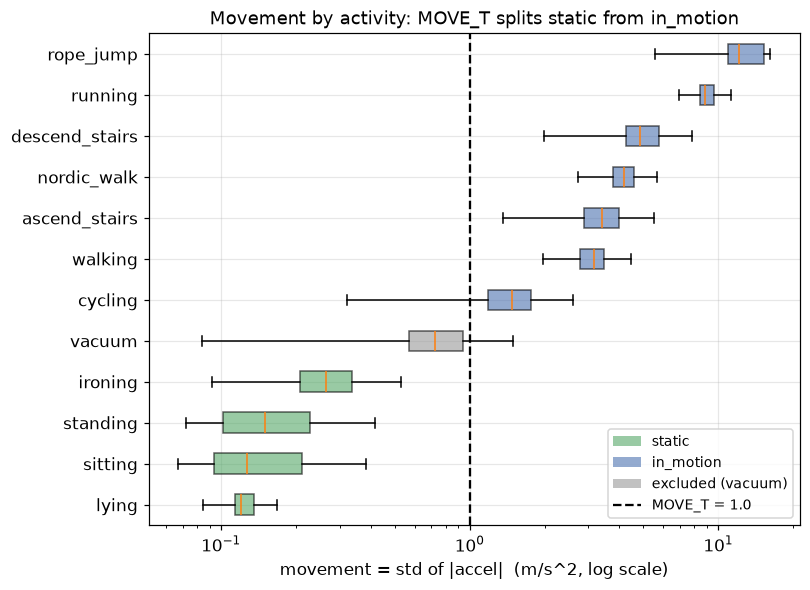

static    : median 0.156  95th 0.532 m/s^2  -> above MOVE_T (false in_motion): 1.0%
in_motion : median 3.548  5th  0.908 m/s^2  -> below MOVE_T (missed motion): 6.1% (mostly low-effort cycling)


In [5]:
STATIC = [a for a, p in TRUE_POSTURE.items() if p != "in_motion"]
MOTION = [a for a, p in TRUE_POSTURE.items() if p == "in_motion"]

def act_color(a):
    p = TRUE_POSTURE.get(a)
    if p is None:        return "#999999"      # excluded from validation (vacuum)
    return "#4C72B0" if p == "in_motion" else "#55A868"

# movement (std of |accel|) per activity, ordered by median
order = res.groupby("activity")["movement"].median().sort_values().index.tolist()
data = [res.loc[res.activity == a, "movement"].to_numpy() for a in order]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
bp = ax.boxplot(data, orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True)
for patch, a in zip(bp["boxes"], order):
    patch.set_facecolor(act_color(a)); patch.set_alpha(0.6)
line = ax.axvline(MOVE_T, ls="--", color="black", label=f"MOVE_T = {MOVE_T}")
ax.set_xscale("log")
ax.set_xlabel("movement = std of |accel|  (m/s^2, log scale)")
ax.set_title("Movement by activity: MOVE_T splits static from in_motion")
ax.legend(handles=[Patch(facecolor="#55A868", alpha=0.6, label="static"),
                   Patch(facecolor="#4C72B0", alpha=0.6, label="in_motion"),
                   Patch(facecolor="#999999", alpha=0.6, label="excluded (vacuum)"), line],
          loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

stat_mv = res[res.activity.isin(STATIC)]["movement"]
mot_mv = res[res.activity.isin(MOTION)]["movement"]
print(f"static    : median {stat_mv.median():.3f}  95th {stat_mv.quantile(.95):.3f} m/s^2  -> above MOVE_T (false in_motion): {(stat_mv > MOVE_T).mean()*100:.1f}%")
print(f"in_motion : median {mot_mv.median():.3f}  5th  {mot_mv.quantile(.05):.3f} m/s^2  -> below MOVE_T (missed motion): {(mot_mv <= MOVE_T).mean()*100:.1f}% (mostly low-effort cycling)")

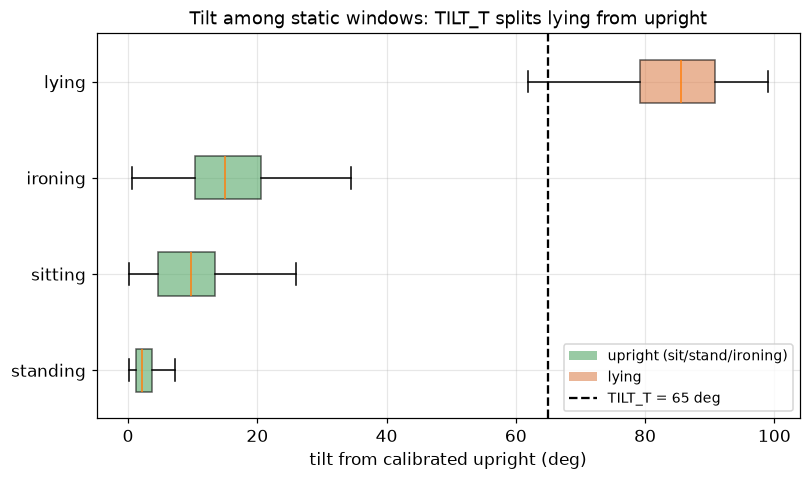

upright (sit/stand/ironing): median 8.3 deg  max 59.7 deg
lying                      : median 85.6 deg  5th 34.3 deg
TILT_T=65 sits above the upright max -> upright never read as lying; 8.2% of lying (low-tilt reclined/side) read as upright


In [6]:
# tilt among static, non-moving windows; lying should sit far above upright
st = res[(res.activity.isin(STATIC)) & (res.movement <= MOVE_T)]
order = ["standing", "sitting", "ironing", "lying"]
data = [st.loc[st.activity == a, "tilt"].to_numpy() for a in order]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bp = ax.boxplot(data, orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True)
for patch, a in zip(bp["boxes"], order):
    patch.set_facecolor("#DD8452" if a == "lying" else "#55A868"); patch.set_alpha(0.6)
line = ax.axvline(TILT_T, ls="--", color="black", label=f"TILT_T = {TILT_T:.0f} deg")
ax.set_xlabel("tilt from calibrated upright (deg)")
ax.set_title("Tilt among static windows: TILT_T splits lying from upright")
ax.legend(handles=[Patch(facecolor="#55A868", alpha=0.6, label="upright (sit/stand/ironing)"),
                   Patch(facecolor="#DD8452", alpha=0.6, label="lying"), line],
          loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

ly = st[st.activity == "lying"]["tilt"]
upr = st[st.activity != "lying"]["tilt"]
print(f"upright (sit/stand/ironing): median {upr.median():.1f} deg  max {upr.max():.1f} deg")
print(f"lying                      : median {ly.median():.1f} deg  5th {ly.quantile(.05):.1f} deg")
print(f"TILT_T={TILT_T:.0f} sits above the upright max -> upright never read as lying; "
      f"{(ly <= TILT_T).mean()*100:.1f}% of lying (low-tilt reclined/side) read as upright")

## 5. Validation
Subject-independent: the thresholds are fixed for everyone (not fit per subject); only the upright reference is per-subject self-calibration. Each activity is mapped to the posture it should read (vacuum excluded). Three numbers separate the easy part from the real question: (a) overall including in_motion; (b) static-only lying-vs-upright — the real posture question; and (c) a held-out lying-vs-sitting test with standing excluded, so the calibration class cannot leak into the score.

(a) overall, incl. in_motion      : 95.4%   (n=5556)
(b) static only, lying vs upright : 96.9%   (n=2852)   <- the real posture question
(c) held-out lying vs sitting     : 94.4%   (n=1416)   <- standing excluded, no calibration leakage


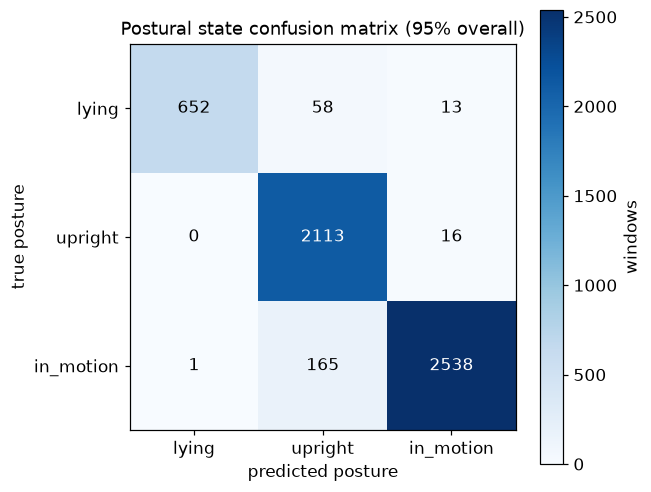

In [7]:
ev = res[res.activity.isin(TRUE_POSTURE)].copy()
ev["true"] = ev.activity.map(TRUE_POSTURE)

# (a) overall, (b) static only, (c) held-out lying-vs-sitting with standing (the calibration class) excluded
overall = (ev["true"] == ev["verdict"]).mean()
stat = ev[ev["true"] != "in_motion"]
static_acc = (stat["true"] == stat["verdict"]).mean()
held = res[res.activity.isin(["lying", "sitting"])].copy()
held["true"] = held.activity.map({"lying": "lying", "sitting": "upright"})
held_acc = (held["true"] == held["verdict"]).mean()

print(f"(a) overall, incl. in_motion      : {overall*100:.1f}%   (n={len(ev)})")
print(f"(b) static only, lying vs upright : {static_acc*100:.1f}%   (n={len(stat)})   <- the real posture question")
print(f"(c) held-out lying vs sitting     : {held_acc*100:.1f}%   (n={len(held)})   <- standing excluded, no calibration leakage")

cm = confusion_matrix(ev["true"], ev["verdict"], labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), CLASSES); ax.set_yticks(range(3), CLASSES)
ax.set_xlabel("predicted posture"); ax.set_ylabel("true posture")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, label="windows")
ax.set_title(f"Postural state confusion matrix ({overall*100:.0f}% overall)")
ax.grid(False)
plt.tight_layout(); plt.show()

## 6. Sitting vs standing — the merge
Why `upright` merges the two static postures. For each subject, the mean gravity vector during sitting and during standing, and the angle between them. The separation is small — below the spread of tilt within a single posture (Section 4) — so a single chest accelerometer cannot place a reliable threshold between them. Presented as a measured proposal back to the mentor.

Per-subject sit-vs-stand mean-gravity angle:
 subject  angle_deg
     101        4.3
     102        4.4
     103       10.8
     104       14.3
     105       16.3
     106        7.9
     107        8.1
     108        3.7

range 3.7-16.3 deg, median 8.0 deg
for context, sitting tilt alone spans 2.3-23.8 deg (5th-95th);
the sit-vs-stand separation is below this within-posture spread, so tilt cannot split them -> merge into upright


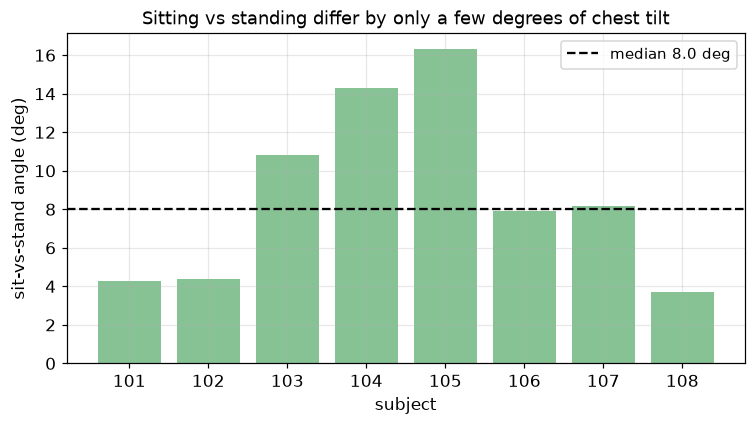

In [8]:
rows_ss = []
for subj, c in calib.items():
    if c["sit"] is None:
        continue
    rows_ss.append((subj, tilt_angle(c["sit"], c["stand"])))
ss = pd.DataFrame(rows_ss, columns=["subject", "angle_deg"]).sort_values("subject")
print("Per-subject sit-vs-stand mean-gravity angle:")
print(ss.to_string(index=False, float_format=lambda x: f"{x:.1f}"))
print(f"\nrange {ss.angle_deg.min():.1f}-{ss.angle_deg.max():.1f} deg, median {ss.angle_deg.median():.1f} deg")

# context: the within-posture tilt spread a threshold would have to beat
sit_tilt = st[st.activity == "sitting"]["tilt"]
print(f"for context, sitting tilt alone spans {sit_tilt.quantile(.05):.1f}-{sit_tilt.quantile(.95):.1f} deg (5th-95th);")
print("the sit-vs-stand separation is below this within-posture spread, so tilt cannot split them -> merge into upright")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ss.subject.astype(str), ss.angle_deg, color="#55A868", alpha=0.7)
ax.axhline(ss.angle_deg.median(), ls="--", color="black", label=f"median {ss.angle_deg.median():.1f} deg")
ax.set_xlabel("subject"); ax.set_ylabel("sit-vs-stand angle (deg)")
ax.set_title("Sitting vs standing differ by only a few degrees of chest tilt")
ax.legend()
plt.tight_layout(); plt.show()

### Findings
- **The rule works on the question that matters.** Static lying-vs-upright is ~97% and the held-out lying-vs-sitting test (standing excluded, so the calibration class cannot leak) is ~94%; overall including in_motion is ~95%. Lying swings chest gravity ~85 deg off the standing axis, so it is an easy, well-separated call. Upright is never misread as lying (`TILT_T` sits above the whole upright distribution); the residual error is a small fraction of low-tilt reclined / side lying read as upright, plus low-effort cycling read as upright.
- **These numbers are on the easy setup.** Chest placement and labeled-standing calibration are both easier than pocket deployment; read the figures as an upper bound, not a deployment estimate.
- **Calibration is a dataset luxury (deferred).** The per-subject `up` reference comes from labeled standing windows, which do not exist at runtime; one of nine subjects (109) has no labeled standing and could not be calibrated at all — a concrete instance of the problem. The known fix is walking-reference calibration: the gravity vector averaged during walking gives the upright direction without a labeled-standing class, with `activity_state` supplying the walking flag (trunk gravity-vector / tilt-correction, Moe-Nilssen, *Clinical Biomechanics* 1998). Deferred to the deep pass.
- **Phone-on-table false positive (deferred).** A still device resting on a surface reads the same gravity geometry as a still body lying down, so it would be called `lying`. A future stillness / undefined gate (separating a held device from a worn one) is needed; not addressed here.
- **Convergence debt — worst on this axis.** Posture depends on body-relative gravity direction, so chest != pocket transfer hurts here more than on the motion axes. `MOVE_T` is in chest m/s^2 and will need unit conversion on a g-scale pocket stream — the same break logged in the convergence test for `MOVEMENT_FLOOR`. Pocket validation is owed.
- **Sit vs stand is a tilt dead end, recoverable only by texture.** Sitting and standing differ by a few-to-several degrees of chest tilt (Section 6), below single-accelerometer resolution, so v1 merges them into `upright`. The path to a 4th state is micro-movement texture (postural sway), not tilt; noted for a future loop.
- **Scope.** Method and validation only — no confidence and no HSI emission this loop.